In [35]:
from config_feature_test import FEATURES, LABEL
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Gemeinsames Dataset laden
df = pd.read_parquet('preprocessed_custom_data.parquet')


In [36]:
# 1. Label umwandeln: 'attack' → 1, 'benign' → 0
df[LABEL] = df[LABEL].map({'attack': 1, 'benign': 0})

# 2. Features und Label auswählen
X = df[FEATURES]
y = df[LABEL]

# 3. Features skalieren (Scaler auf komplettes Dataset)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [37]:
df.head(-1)

,timestamp,ase_spec,br_immed_spec,br_indirect_spec,br_mis_pred,br_pred,br_return_spec,branch-load-misses,branch-loads,branch-misses,...,writeback_writeback_single_inode,writeback_writeback_single_inode_start,writeback_writeback_start,writeback_writeback_wait,writeback_writeback_wait_iff_congested,writeback_writeback_wake_background,writeback_writeback_write_inode,writeback_writeback_written,attack,Label
0,2025-07-22T18:00:00,842.0,534639.0,114176.0,14852.0,648716.0,95435.0,15470.0,657359.0,16248.0,...,546520,546520,1327414,0,0,210,470339,1327414,benign,0
1,2025-07-22T18:00:10,830.0,530504.0,113038.0,14845.0,643445.0,94416.0,14958.0,649089.0,15080.0,...,546522,546522,1327426,0,0,210,470341,1327426,benign,0
2,2025-07-22T18:00:20,775.0,530791.0,113318.0,15235.0,644009.0,94677.0,16126.0,678009.0,14637.0,...,546525,546525,1327439,0,0,210,470344,1327439,benign,0
3,2025-07-22T18:00:30,895.0,533606.0,113935.0,14633.0,647442.0,95136.0,15474.0,646697.0,14399.0,...,546528,546528,1327450,0,0,210,470346,1327450,benign,0
4,2025-07-22T18:00:40,822.0,536215.0,114003.0,15363.0,650120.0,95225.0,14512.0,640024.0,14608.0,...,546530,546530,1327461,0,0,210,470348,1327461,benign,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6788,2025-07-23T12:51:20,865.0,536569.0,115208.0,15914.0,651677.0,96198.0,15994.0,665344.0,15742.0,...,587080,587080,1416981,0,0,233,505991,1416981,benign,0
6789,2025-07-23T12:51:30,865.0,536569.0,115208.0,15914.0,651677.0,96198.0,15994.0,665344.0,15742.0,...,587080,587080,1416981,0,0,233,505991,1416981,benign,0
6790,2025-07-23T12:51:40,865.0,536569.0,115208.0,15914.0,651677.0,96198.0,15994.0,665344.0,15742.0,...,587080,587080,1416981,0,0,233,505991,1416981,benign,0
6791,2025-07-23T12:51:50,865.0,536569.0,115208.0,15914.0,651677.0,96198.0,15994.0,665344.0,15742.0,...,587080,587080,1416981,0,0,233,505991,1416981,benign,0


In [39]:
import numpy as np

def create_sequences(X, y, window_size=5):
    X_seq = []
    y_seq = []
    for i in range(len(X) - window_size + 1):
        label_window = y[i:i+window_size]
        # Nur wenn alle Labels im Fenster gleich sind
        if np.all(label_window == label_window[0]):
            X_seq.append(X[i:i+window_size])
            y_seq.append(label_window[0])
    return np.array(X_seq), np.array(y_seq)

# Anwendung auf deine Daten (jetzt mit window_size=5)
X_sequences, y_sequences = create_sequences(X_scaled, y.values, window_size=5)


In [25]:
# Statt nur homogene Labels:
def create_sequences_mixed(X, y, window_size=10):
    X_seq = []
    y_seq = []
    for i in range(len(X) - window_size + 1):
        label_window = y[i:i+window_size]
        X_seq.append(X[i:i+window_size])
        # Attack, wenn mindestens ein Angriff im Fenster ist
        y_seq.append(1 if np.any(label_window == 1) else 0)
    return np.array(X_seq), np.array(y_seq)


In [40]:
print(X_sequences.shape)  # (Anzahl Fenster, 10, Anzahl Features)
print(y_sequences.shape)  # (Anzahl Fenster,)


(6678, 5, 20)
(6678,)


In [41]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Function to create a stacked LSTM model
def create_lstm_model(num_features):
    model = Sequential([
        # First LSTM layer (returns full sequences for stacking)
        LSTM(30, input_shape=(10, num_features), return_sequences=True),
        Dropout(0.2),  # Dropout to prevent overfitting
        # Second LSTM layer (only returns final output)
        LSTM(15),
        Dropout(0.2),  # Additional regularization
        # Output layer for binary classification
        Dense(1, activation='sigmoid')
    ])
    
    # Compile model with binary crossentropy loss and accuracy metric
    model.compile(
        loss='binary_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    return model

# Create model with number of selected input features
model = create_lstm_model(len(FEATURES))

# Print model summary
model.summary()

# Print number of selected features
print(len(FEATURES))

/home/yannic/Desktop/Uni/Semester8_Regensburg/Bachelorarbeit/bachelor/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 10, 30)         │         6,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 10, 30)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 15)             │         2,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 15)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,896 (34.75 KB)

 Trainable params: 8,896 (34.75 KB)

 Non-trainable params: 0 (0.00 B)

20


In [42]:
history = model.fit(
    X_sequences, y_sequences,
    epochs=20,         # Anzahl der Durchläufe, du kannst anpassen
    batch_size=64,     # Größe der Trainingsbatches (vorerst Standard)
    validation_split=0.2  # 20% der Daten werden für Validierung verwendet
)


Epoch 1/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8374 - loss: 0.4637 - val_accuracy: 0.5674 - val_loss: 0.6276
Epoch 2/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9799 - loss: 0.0876 - val_accuracy: 0.7747 - val_loss: 0.5357
Epoch 3/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9841 - loss: 0.0570 - val_accuracy: 0.7987 - val_loss: 0.5069
Epoch 4/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9840 - loss: 0.0392 - val_accuracy: 0.7874 - val_loss: 0.5073
Epoch 5/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9848 - loss: 0.0367 - val_accuracy: 0.7388 - val_loss: 0.5209
Epoch 6/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9870 - loss: 0.0281 - val_accuracy: 0.5606 - val_loss: 0.6062
Epoch 7/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9892 - loss: 0.0252 - val_accuracy: 0.5786 - val_loss: 0.6059
Epoch 8/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9879 - loss: 0.0268 - val_accuracy: 0.5172 - val_loss:

In [43]:
from sklearn.metrics import accuracy_score, classification_report

# 1. Vorhersage auf allen Sequenzdaten machen
y_pred_prob = model.predict(X_sequences)

# 2. Wahrscheinlichkeiten in Klassenlabels umwandeln
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# 3. Genauigkeit und Klassifikationsbericht berechnen
accuracy = accuracy_score(y_sequences, y_pred)
report = classification_report(y_sequences, y_pred)

# 4. Ausgabe
print(f"Genauigkeit: {accuracy:.4f}")
print(report)


209/209 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Genauigkeit: 0.8763
              precision    recall  f1-score   support

           0       0.99      0.86      0.92      5800
           1       0.52      0.96      0.67       878

    accuracy                           0.88      6678
   macro avg       0.75      0.91      0.80      6678
weighted avg       0.93      0.88      0.89      6678



209/209 ━━━━━━━━━━━━━━━━━━━━ 0s 838us/step
[[5013  787]
 [  39  839]]


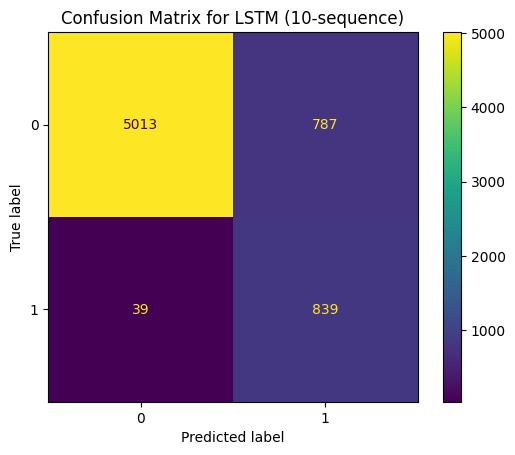

In [44]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import os

# 1. Vorhersage (Klassenzuordnung) für alle Sequenzen
y_pred_seq = (model.predict(X_sequences) > 0.5).astype(int).flatten()

# 2. Confusion Matrix berechnen
cm = confusion_matrix(y_sequences, y_pred_seq)

# 3. Confusion Matrix als Zahlen ausgeben
print(cm)

# 4. Confusion Matrix als Grafik anzeigen
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title('Confusion Matrix for LSTM (10-sequence)')

# 5. Grafik speichern
output_dir = "/home/yannic/Desktop/Uni/Semester8_Regensburg/Bachelorarbeit/graffics_for_BA/feature_plots"
filename = "confusion_matrix.png"
filepath = os.path.join(output_dir, filename)
plt.savefig(filepath, dpi=300)
plt.show()


In [46]:
import pandas as pd
import numpy as np

window_size = 5

# 1. Das ursprüngliche Attack-Array holen (aus dem vollständigen DataFrame)
attack_array = df["attack"].values   # Hier ist df dein gesamtes DataFrame
y_array = y.values                  # Die Labels, wie vorher erzeugt

# 2. Für jedes Fenster mit konstantem Label: Attack-Typ des ersten Elements speichern
attack_seq = np.array([
    attack_array[i]
    for i in range(len(attack_array) - window_size + 1)
    if np.all(y_array[i:i+window_size] == y_array[i])
])

# 3. DataFrame kombinieren: Wahres Label, Vorhersage, Attack-Typ
df_summary = pd.DataFrame({
    "y_true": y_sequences,
    "y_pred": y_pred_seq,
    "attack": attack_seq
})

# 4. Falsch erkannte Angriffe herausfiltern (eigentlich Angriff, aber Modell sagt "keine Attacke")
misclassified = df_summary[(df_summary["y_true"] == 1) & (df_summary["y_pred"] == 0)]

# 5. Anzahl falscher und aller Angriffe je Typ zählen
misclassified_counts = misclassified["attack"].value_counts()
total_counts = df_summary[df_summary["y_true"] == 1]["attack"].value_counts()

# 6. Zusammenfassen in eine Übersichtstabelle
summary = pd.DataFrame({
    "misclassified": misclassified_counts,
    "total": total_counts
}).fillna(0).astype(int)

# 7. Tabelle ausgeben (sortiert nach den falsch Erkannten)
print(summary.sort_values("misclassified", ascending=False))


                  misclassified  total
attack                                
slowloris                    34    142
portscan                      5     73
icmpflood                     0    173
aggressivescan                0     56
osfingerprinting              0     56
synonymousflood               0    114
tcpflood                      0    134
udpflood                      0    130


209/209 ━━━━━━━━━━━━━━━━━━━━ 0s 874us/step
209/209 ━━━━━━━━━━━━━━━━━━━━ 0s 855us/step
209/209 ━━━━━━━━━━━━━━━━━━━━ 0s 852us/step
209/209 ━━━━━━━━━━━━━━━━━━━━ 0s 838us/step
209/209 ━━━━━━━━━━━━━━━━━━━━ 0s 860us/step
209/209 ━━━━━━━━━━━━━━━━━━━━ 0s 858us/step
209/209 ━━━━━━━━━━━━━━━━━━━━ 0s 824us/step
209/209 ━━━━━━━━━━━━━━━━━━━━ 0s 877us/step
209/209 ━━━━━━━━━━━━━━━━━━━━ 0s 873us/step
209/209 ━━━━━━━━━━━━━━━━━━━━ 0s 831us/step
209/209 ━━━━━━━━━━━━━━━━━━━━ 0s 797us/step
209/209 ━━━━━━━━━━━━━━━━━━━━ 0s 821us/step
209/209 ━━━━━━━━━━━━━━━━━━━━ 0s 824us/step
209/209 ━━━━━━━━━━━━━━━━━━━━ 0s 824us/step
209/209 ━━━━━━━━━━━━━━━━━━━━ 0s 800us/step
209/209 ━━━━━━━━━━━━━━━━━━━━ 0s 793us/step
209/209 ━━━━━━━━━━━━━━━━━━━━ 0s 823us/step
209/209 ━━━━━━━━━━━━━━━━━━━━ 0s 792us/step
209/209 ━━━━━━━━━━━━━━━━━━━━ 0s 813us/step
209/209 ━━━━━━━━━━━━━━━━━━━━ 0s 822us/step
209/209 ━━━━━━━━━━━━━━━━━━━━ 0s 853us/step


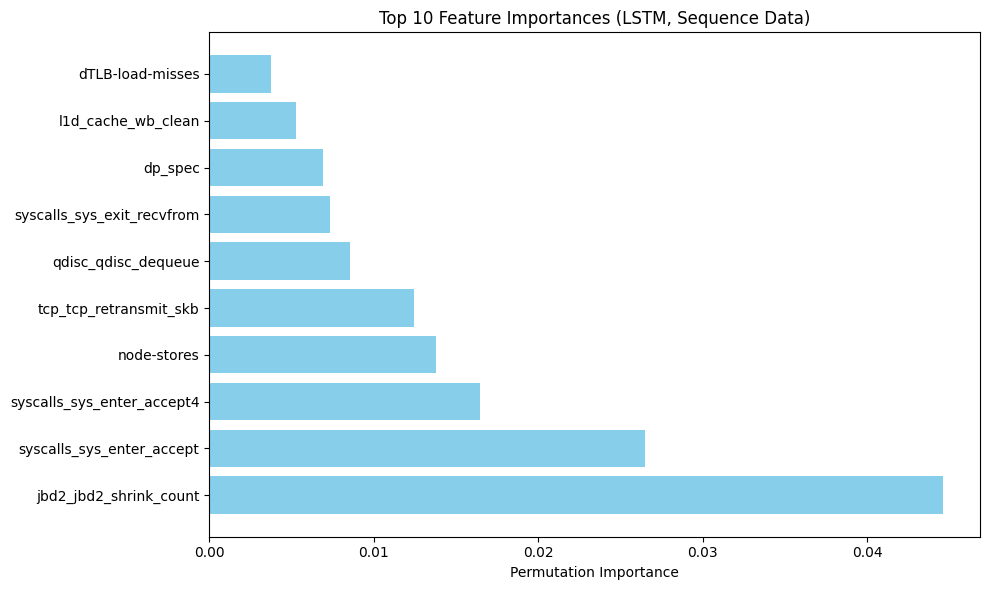

In [47]:
import numpy as np
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import os

# Annahme: model, X_sequences, y_sequences, FEATURES sind schon definiert

# 1. Baseline-Genauigkeit auf den Sequenzdaten
y_pred_seq = model.predict(X_sequences)
original_acc = accuracy_score(y_sequences, (y_pred_seq > 0.5).astype(int))

feature_importances = []
for i in range(X_sequences.shape[2]):
    X_test_perm = X_sequences.copy()
    # Permutiere das i-te Merkmal (über alle Zeitfenster und alle Zeitpunkte!)
    np.random.shuffle(X_test_perm[:, :, i])
    y_pred_perm = model.predict(X_test_perm)
    perm_acc = accuracy_score(y_sequences, (y_pred_perm > 0.5).astype(int))
    feature_importances.append(original_acc - perm_acc)

# 2. Top-10-Merkmale finden
indices_top10 = np.argsort(feature_importances)[-10:][::-1]
top10_features = [FEATURES[i] for i in indices_top10]
top10_importances = [feature_importances[i] for i in indices_top10]

# 3. Balkendiagramm für die Top-10
plt.figure(figsize=(10, 6))
plt.barh(top10_features, top10_importances, color='skyblue')
plt.xlabel('Permutation Importance')
plt.title('Top 10 Feature Importances (LSTM, Sequence Data)')
plt.tight_layout()
output_dir = "/home/yannic/Desktop/Uni/Semester8_Regensburg/Bachelorarbeit/graffics_for_BA/feature_plots"
filename = "feature_importances_lstm.png"
filepath = os.path.join(output_dir, filename)
plt.savefig(filepath, dpi=300)
plt.show()


In [39]:
print(top20_features)


NameError: name 'top20_features' is not defined

In [48]:
from tensorflow.keras.models import load_model
import joblib

model.save('lstm_model_20events.h5')
joblib.dump(scaler, "scaler.pkl")


['scaler.pkl']

In [49]:
print(scaler.feature_names_in_)


['syscalls_sys_enter_accept' 'qdisc_qdisc_dequeue'
 'jbd2_jbd2_shrink_count' 'bus-cycles' 'bus_access_not_shared'
 'tcp_tcp_retransmit_skb' 'syscalls_sys_enter_accept4'
 'l2d_cache_refill_rd' 'br_mis_pred' 'l2d_cache_wb' 'node-stores'
 'l1d_cache_wb_clean' 'dp_spec' 'syscalls_sys_exit_recvfrom'
 'dTLB-load-misses' 'node-loads' 'mem_access' 'iTLB-load-misses'
 'jbd2_jbd2_checkpoint_stats' 'syscalls_sys_enter_fchmod']
